# Import Library

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve)
import shap
import joblib

os.makedirs('output/figures', exist_ok=True)
os.makedirs('output/models', exist_ok=True)
for path in ['output', 'output/figures', 'output/models']:
    os.makedirs(path, exist_ok=True)

# Data Acquisition

In [ ]:
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vQsD_VTO--C2WW1dDOMoVEd-VslZNt_Jf10Ong5gdXZImeImtCA1LUghD2nkAT5SgmfONfQDVaNMSRr/pub?gid=833901771&single=true&output=csv'
df = pd.read_csv(url)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Mengecek dimensi data (baris, kolom)
print(df.shape)

(7043, 21)


In [ ]:
# Mengecek tipe data dan memori
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Menampilkan statistik deskriptif dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# Mengecek mising value
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
TotalCharges,11


# Data Cleaning

In [ ]:
# Handling TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"   - Ditemukan nilai kosong di TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Imputasi dengan MEDIAN
median_val = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_val)
print(f"   - Diisi dengan nilai median: {median_val:.2f}")

# Drop customerID (tidak relevan untuk predictive modeling)
df = df.drop('customerID', axis=1)

# Konversi target Churn ke binary (0 dan 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("   - Yes = 1 (Churn), No = 0 (Setia)")
assert df['Churn'].notnull().all(), "Ada nilai Churn yang tidak valid!"
assert df['Churn'].isin([0, 1]).all(), "Churn harus hanya berisi 0 atau 1!"

# Verifikasi hasil cleaning
print(f"\n DATA CLEANING SELESAI")
print(f"   Total missing values tersisa: {df.isnull().sum().sum()}")
print(f"   Shape data saat ini: {df.shape}")

# Simpan metadata untuk production
cleaning_metadata = {
    'TotalCharges_median': median_val,
    'dropped_columns': ['customerID'],
    'target_mapping': {'Yes': 1, 'No': 0},
    'cleaning_date': pd.Timestamp.now()
}

   - Ditemukan nilai kosong di TotalCharges: 11
   - Diisi dengan nilai median: 1397.47
   - Yes = 1 (Churn), No = 0 (Setia)

 DATA CLEANING SELESAI
   Total missing values tersisa: 0
   Shape data saat ini: (7043, 20)


# EDA (Exploratory Data Analysis)

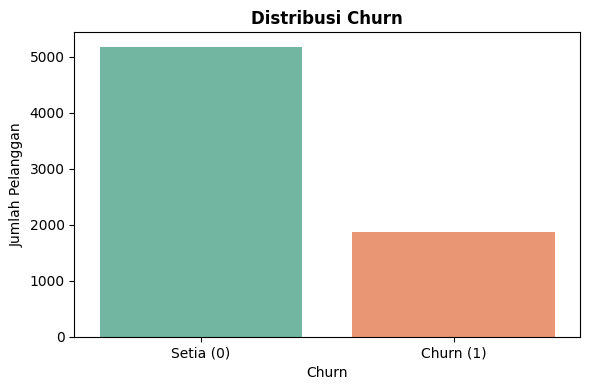

Churn Rate: 26.5%
   - Setia: 5174 pelanggan
   - Churn: 1869 pelanggan


In [ ]:
# DISTRIBUSI CHURN
os.makedirs('output/figures', exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribusi Churn', fontweight='bold')
plt.xticks([0, 1], ['Setia (0)', 'Churn (1)'])
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.savefig('output/figures/01_distribusi_churn.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Churn Rate: {df['Churn'].mean()*100:.1f}%")
print(f"   - Setia: {(df['Churn']==0).sum()} pelanggan")
print(f"   - Churn: {(df['Churn']==1).sum()} pelanggan")

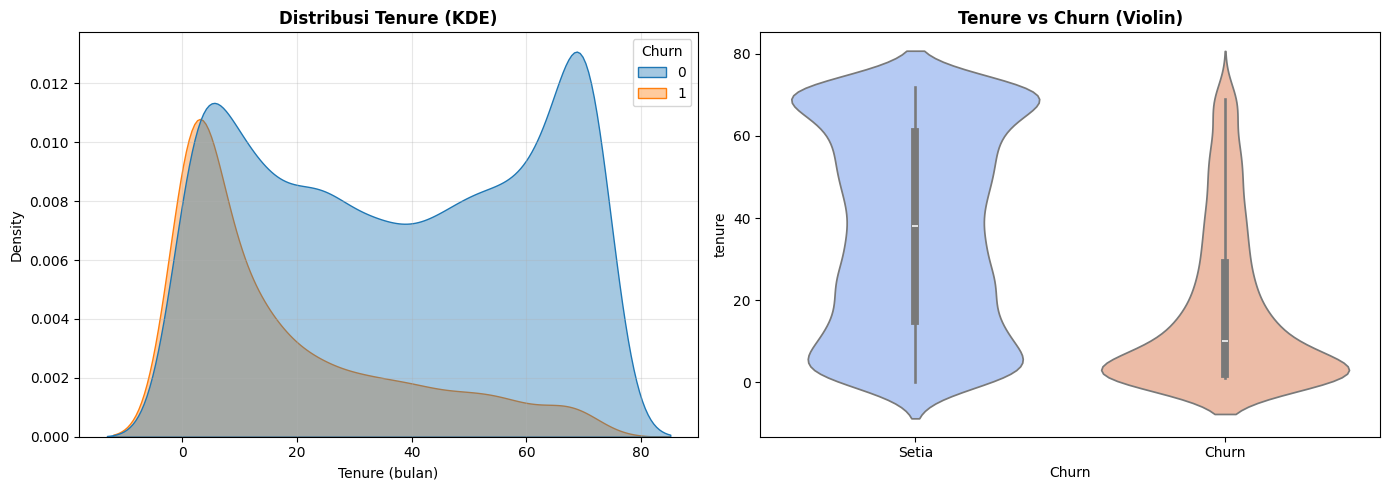

Insight Tenure:
   - Rata-rata tenure pelanggan Setia: 37.6 bulan
   - Rata-rata tenure pelanggan Churn: 18.0 bulan
   - Pelanggan baru (<12 bulan) lebih berisiko churn


In [ ]:
# TENURE VS CHURN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE Plot
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Distribusi Tenure (KDE)', fontweight='bold')
axes[0].set_xlabel('Tenure (bulan)')
axes[0].grid(alpha=0.3)

# Violin Plot
sns.violinplot(data=df, x='Churn', y='tenure', palette='coolwarm', ax=axes[1])
axes[1].set_title('Tenure vs Churn (Violin)', fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Setia', 'Churn'])

plt.tight_layout()
plt.savefig('output/figures/02_tenure_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Insight
print("Insight Tenure:")
print(f"   - Rata-rata tenure pelanggan Setia: {df[df['Churn']==0]['tenure'].mean():.1f} bulan")
print(f"   - Rata-rata tenure pelanggan Churn: {df[df['Churn']==1]['tenure'].mean():.1f} bulan")
print(f"   - Pelanggan baru (<12 bulan) lebih berisiko churn")

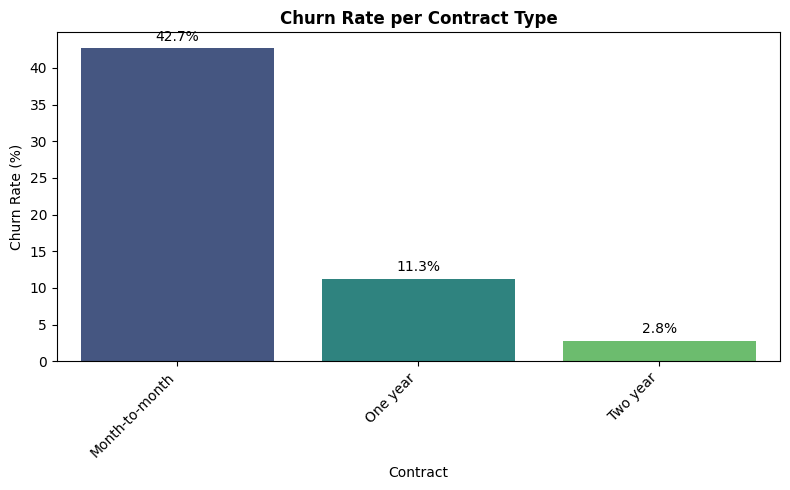

Insight Contract:
   - Tertinggi: Month-to-month (42.7%)
   - Terendah: Two year (2.8%)
   - Fokus retensi pada Month-to-month customers!


In [ ]:
# CHURN RATE PER CONTRACT

plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
bars = sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='viridis')
plt.title('Churn Rate per Contract Type', fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract')
plt.xticks(rotation=45, ha='right')

# Tambah label nilai
for i, v in enumerate(contract_churn.values):
    bars.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('output/figures/03_contract_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print("Insight Contract:")
print(f"   - Tertinggi: {contract_churn.index[0]} ({contract_churn.values[0]:.1f}%)")
print(f"   - Terendah: {contract_churn.index[-1]} ({contract_churn.values[-1]:.1f}%)")
print(f"   - Fokus retensi pada Month-to-month customers!")

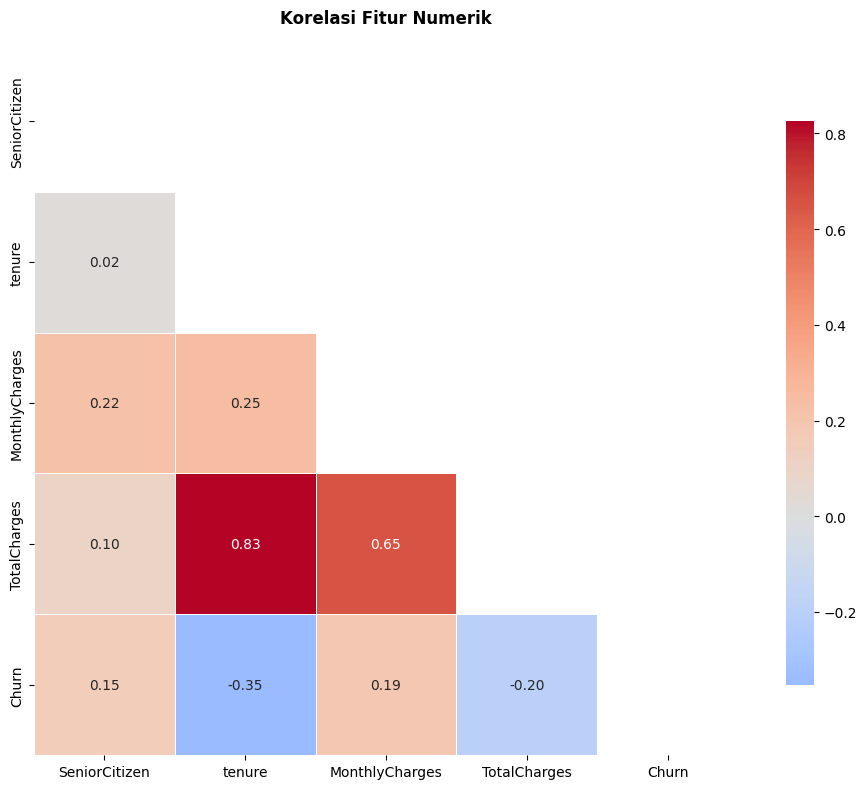

📊 Insight Korelasi:
   - tenure vs Churn: -0.35 (negatif = tenure ↑ churn ↓)
   - MonthlyCharges vs Churn: 0.19


In [ ]:
# KORELASI FITUR NUMERIK

# Identifikasi fitur numerik
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Churn' in numerical_features:
    numerical_features.remove('Churn')

plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_features + ['Churn']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Korelasi Fitur Numerik', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output/figures/04_korelasi_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Insight Korelasi:")
print(f"   - tenure vs Churn: {corr_matrix.loc['tenure', 'Churn']:.2f} (negatif = tenure ↑ churn ↓)")
print(f"   - MonthlyCharges vs Churn: {corr_matrix.loc['MonthlyCharges', 'Churn']:.2f}")

In [ ]:
# EDA SUMMARY

# Hitung metrik utama
churn_rate = df['Churn'].mean() * 100
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
corr_tenure_churn = df['tenure'].corr(df['Churn'])

print("Insight Utama:")
print(f"   - Churn Rate: {churn_rate:.1f}%")
print(f"   - Contract dengan churn tertinggi: {contract_churn.index[0]} ({contract_churn.values[0]:.1f}%)")
print(f"   - Korelasi tenure-Churn: {corr_tenure_churn:.2f}")

Insight Utama:
   - Churn Rate: 26.5%
   - Contract dengan churn tertinggi: Month-to-month (42.7%)
   - Korelasi tenure-Churn: -0.35


# Feature Encoding

In [ ]:
# Pisah features (X) dan target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identifikasi tipe fitur
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Fitur Numerik ({len(numerical_features)}):")
for col in numerical_features:
    print(f"   - {col}")

print(f"\n Fitur Kategorikal ({len(categorical_features)}):")
for col in categorical_features:
    print(f"   - {col}")

# Setup ColumnTransformer untuk preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Standarisasi numerik
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)  # Encoding kategorikal
    ])

Fitur Numerik (4):
   - SeniorCitizen
   - tenure
   - MonthlyCharges
   - TotalCharges

 Fitur Kategorikal (15):
   - gender
   - Partner
   - Dependents
   - PhoneService
   - MultipleLines
   - InternetService
   - OnlineSecurity
   - OnlineBackup
   - DeviceProtection
   - TechSupport
   - StreamingTV
   - StreamingMovies
   - Contract
   - PaperlessBilling
   - PaymentMethod


# Data Splitting & Pipeline SMOTE

In [ ]:

# DATA SPLITTING & BALANCING

# Split data train-test dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 80% train, 20% test
    random_state=42,
    stratify=y               # Pertahankan proporsi churn
)

# Verifikasi distribusi kelas (baseline sebelum SMOTE)
print(f"Train: {len(X_train):,} samples | Churn: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(X_test):,} samples  | Churn: {y_test.mean()*100:.1f}%")

# Membangun pipeline (Preprocessing + SMOTE + Model)
model_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),           # Scaling & Encoding
    ('smote', SMOTE(random_state=42, k_neighbors=5)),  # Balancing
    ('classifier', lgb.LGBMClassifier(        # Model LightGBM
        objective='binary',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbose=-1
    ))
])

Train: 5,634 samples | Churn: 26.5%
Test:  1,409 samples  | Churn: 26.5%


# Modeling Training LIGHTGBM

In [ ]:
# Training Pipeline (Otomatis: Preprocessing -> SMOTE -> LightGBM)
model_pipeline.fit(X_train, y_train)

# Akses model terlatih
lgb_model = model_pipeline.named_steps['classifier']

# Log hasil training
print(f"Training selesai | Trees: {lgb_model.n_estimators_} | Total Features (after OHE): {lgb_model.n_features_in_}")

Training selesai | Trees: 200 | Total Features (after OHE): 45


# Model Assessment

Threshold optimal ditemukan: 0.30  (F1 tertinggi: 0.6254)

=== MODEL ASSESSMENT ===

Accuracy  : 0.7466
Precision : 0.5147
Recall    : 0.7968
F1-Score  : 0.6254
AUC-ROC   : 0.8340

📋 Classification Report:
              precision    recall  f1-score   support

   Setia (0)       0.91      0.73      0.81      1035
   Churn (1)       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



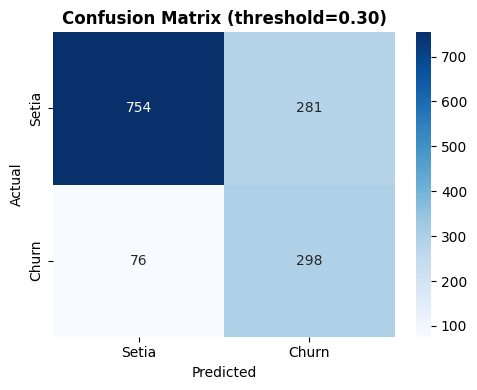


 Evaluasi tersimpan di output/hasil_evaluasi.txt


In [ ]:
# MODEL ASSESSMENT: EVALUASI PERFORMA

# Prediksi probabilitas (digunakan untuk threshold optimization)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.01)
best_thresh, best_f1 = 0.5, 0.0

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    f = f1_score(y_test, y_t)
    if f > best_f1:
        best_f1 = f
        best_thresh = t

print(f"Threshold optimal ditemukan: {best_thresh:.2f}  (F1 tertinggi: {best_f1:.4f})")

# Prediksi menggunakan threshold optimal
y_pred = (y_proba >= best_thresh).astype(int)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_proba)
}

print("\n=== MODEL ASSESSMENT ===\n")
for k, v in metrics.items():
    print(f"{k:<10}: {v:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Setia (0)', 'Churn (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setia', 'Churn'], yticklabels=['Setia', 'Churn'])
plt.title(f'Confusion Matrix (threshold={best_thresh:.2f})', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('output/figures/05_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Simpan Laporan
with open('output/hasil_evaluasi.txt', 'w') as f:
    f.write("MODEL ASSESSMENT RESULTS\n" + "="*30 + "\n")
    f.write(f"Optimal Threshold: {best_thresh:.2f}\n")
    for k, v in metrics.items(): f.write(f"{k}: {v:.4f}\n")
    f.write("\nCLASSIFICATION REPORT:\n" + classification_report(y_test, y_pred, target_names=['Setia', 'Churn']))
print("\n Evaluasi tersimpan di output/hasil_evaluasi.txt")


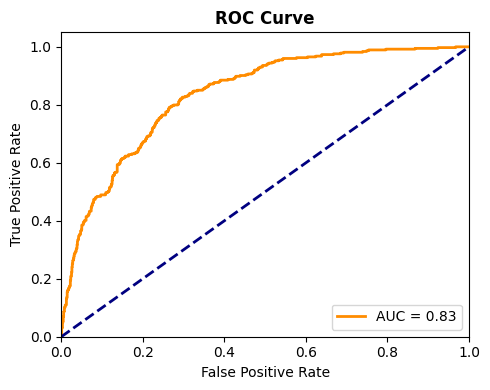

 ROC Curve tersimpan.


In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {metrics["AUC-ROC"]:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('output/figures/06_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(" ROC Curve tersimpan.")


# Explainable AI dengan SHAP

Menghitung SHAP values...


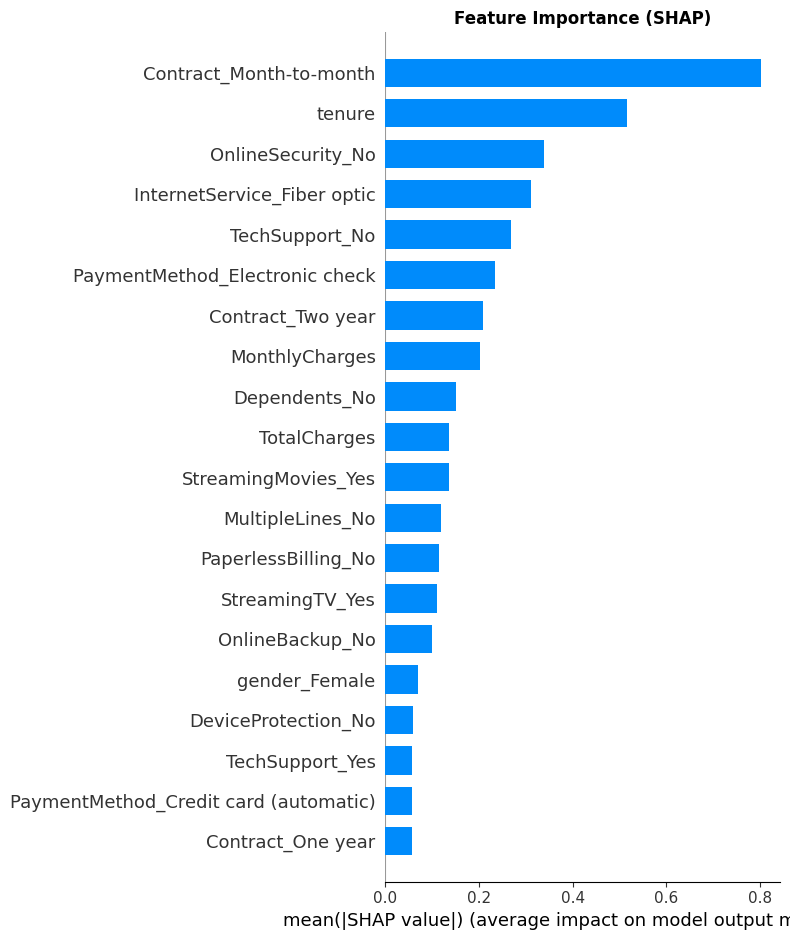

In [ ]:
# EXPLAINABLE AI (XAI) DENGAN SHAP

# Setup Explainer & Transform Data
lgb_model = model_pipeline.named_steps['classifier']
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + cat_feature_names

X_test_transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)

# Hitung SHAP Values
print("Menghitung SHAP values...")
explainer = shap.TreeExplainer(lgb_model)
raw_shap = explainer.shap_values(X_test_transformed)

# LightGBM biner output list [class_0, class_1]. Ambil class 1 (Churn).
shap_values = raw_shap[1] if type(raw_shap) == list else raw_shap

# 3. Feature Importance (Bar Plot)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)", fontweight='bold')
plt.tight_layout()
plt.savefig('output/figures/07_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

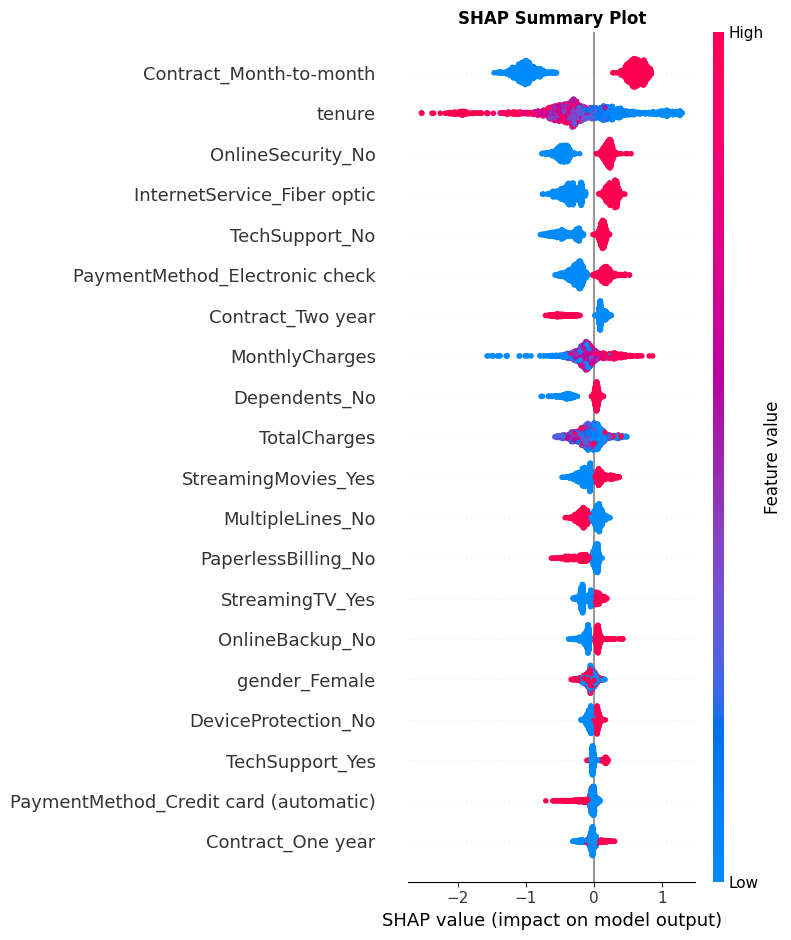

In [ ]:
# SHAP Summary (Beeswarm)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, show=False)
plt.title("SHAP Summary Plot", fontweight='bold')
plt.tight_layout()
plt.savefig('output/figures/08_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

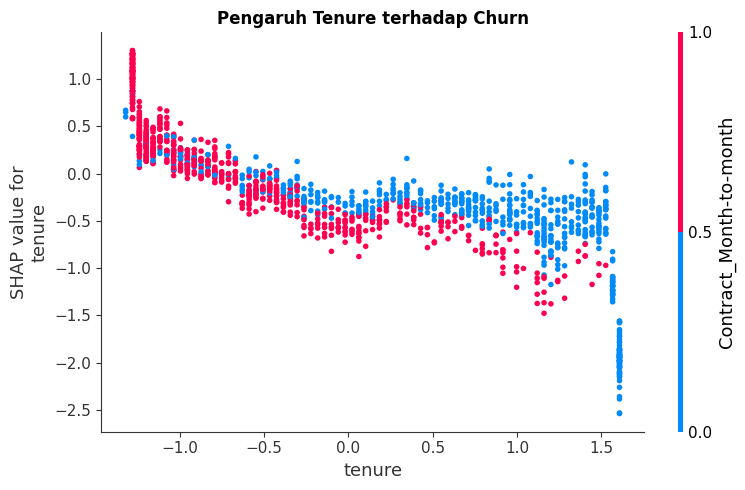


 Contoh Interpretasi (Top 3 Faktor Pemicu Churn):

Sample #1 (Prediksi: Setia):
  • tenure: -1.786
  • Contract_Month-to-month: -1.030
  • Contract_Two year: -0.610

Sample #2 (Prediksi: Churn):
  • Contract_Month-to-month: +0.693
  • MonthlyCharges: +0.661
  • tenure: +0.531

Sample #3 (Prediksi: Setia):
  • Contract_Month-to-month: -1.101
  • InternetService_Fiber optic: -0.412
  • OnlineSecurity_No: -0.388

 Visualisasi SHAP tersimpan.


In [ ]:
# Dependence Plot (Tenure)
shap.dependence_plot("tenure", shap_values, X_test_transformed,
                     feature_names=all_feature_names, show=False)

fig = plt.gcf()          # Tangkap canvas hasil render SHAP
fig.set_size_inches(8, 5) # Resize manual (menghindari canvas kosong)
plt.title("Pengaruh Tenure terhadap Churn", fontweight='bold')
plt.tight_layout()
plt.savefig('output/figures/09_shap_tenure.png', dpi=300)
plt.show()
plt.close()

# Analisis Sampel (Top 3 Faktor)
print("\n Contoh Interpretasi (Top 3 Faktor Pemicu Churn):")
for idx in [0, 1, 2]:
    # Akses baris ke-idx dari array 2D shap_values
    sample_vals = shap_values[idx]
    top_indices = np.argsort(np.abs(sample_vals))[-3:][::-1]

    print(f"\nSample #{idx+1} (Prediksi: {'Churn' if y_pred[idx]==1 else 'Setia'}):")
    for i in top_indices:
        print(f"  • {all_feature_names[i]}: {sample_vals[i]:+.3f}")

print("\n Visualisasi SHAP tersimpan.")

# Policy Simulation (What-IF)

In [ ]:
# POLICY SIMULATION (WHAT-IF)

def simulasi_what_if(data_input, pipeline, perubahan_dict, nama_skenario):
    """Simulasi perubahan kebijakan (support multiple variables)"""
    data_sim = data_input.copy()

    # Terapkan semua perubahan
    for col, val in perubahan_dict.items():
        data_sim[col] = val

    # Prediksi probabilitas churn (index 1 = kelas Churn)
    proba_sebelum = pipeline.predict_proba(data_input)[:, 1]
    proba_sesudah = pipeline.predict_proba(data_sim)[:, 1]

    # Hitung dampak
    dampak = (proba_sesudah - proba_sebelum).mean() * 100

    # Output ringkas
    print(f"\n {nama_skenario}")
    print(f"   Perubahan: {perubahan_dict}")

    # jika ingin menggunakan ini agar tidak terlalu panjang angkanya
    # deskripsi = " | ".join([f"{k} (dimodifikasi)" for k in perubahan_dict.keys()])
    # print(f"   Variabel Diubah: {deskripsi}")

    print(f"   Avg Prob Churn Before: {proba_sebelum.mean():.4f}")
    print(f"   Avg Prob Churn After:  {proba_sesudah.mean():.4f}")
    print(f"   Dampak: {dampak:+.2f}% {' Efektif' if dampak < 0 else '⚠️ Kurang Signifikan'}")

    return dampak

# Filter target: Pelanggan Month-to-month
mask_bulanan = (X_test['Contract'] == 'Month-to-month')
X_bulanan = X_test[mask_bulanan].copy()

if len(X_bulanan) > 0:
    # 1. Diskon 20% MonthlyCharges
    simulasi_what_if(X_bulanan, model_pipeline,
                     {'MonthlyCharges': X_bulanan['MonthlyCharges'] * 0.80},
                     "SIMULASI 1: Diskon 20% MonthlyCharges")

    # 2. Upgrade Contract ke Two Year
    simulasi_what_if(X_bulanan, model_pipeline,
                     {'Contract': 'Two year'},
                     "SIMULASI 2: Upgrade Contract → Two Year")

    # 3. Kombinasi (Perbaikan Bug: Diskon + Upgrade dihitung bersamaan)
    simulasi_what_if(X_bulanan, model_pipeline,
                     {
                         'Contract': 'Two year',
                         'MonthlyCharges': X_bulanan['MonthlyCharges'] * 0.85
                     },
                     "SIMULASI 3: Upgrade Contract + Diskon 15%")
else:
    print("Tidak ada data Month-to-month di test set.")

print("\n Policy Simulation selesai.")


 SIMULASI 1: Diskon 20% MonthlyCharges
   Perubahan: {'MonthlyCharges': 2280    80.12
4460    62.56
5748    79.88
3568    79.32
2976    19.28
        ...  
6399    58.48
4223    56.24
1733    15.24
1421    67.52
3857    16.52
Name: MonthlyCharges, Length: 773, dtype: float64}
   Avg Prob Churn Before: 0.4992
   Avg Prob Churn After:  0.4624
   Dampak: -3.67%  Efektif

 SIMULASI 2: Upgrade Contract → Two Year
   Perubahan: {'Contract': 'Two year'}
   Avg Prob Churn Before: 0.4992
   Avg Prob Churn After:  0.1046
   Dampak: -39.46%  Efektif

 SIMULASI 3: Upgrade Contract + Diskon 15%
   Perubahan: {'Contract': 'Two year', 'MonthlyCharges': 2280    85.1275
4460    66.4700
5748    84.8725
3568    84.2775
2976    20.4850
         ...   
6399    62.1350
4223    59.7550
1733    16.1925
1421    71.7400
3857    17.5525
Name: MonthlyCharges, Length: 773, dtype: float64}
   Avg Prob Churn Before: 0.4992
   Avg Prob Churn After:  0.0895
   Dampak: -40.97%  Efektif

 Policy Simulation selesai.


# Cek Menggunakan 10 sampel acak

In [ ]:
# CHURN PREVENTION DASHBOARD - TESTING 10 SAMPEL

print("=== CHURN PREVENTION DASHBOARD ===")
print("Testing 10 Sampel Data Acak dari Data Uji")
print(f"Threshold Optimal: {best_thresh:.2f}")
print("="*60)

sample_df = X_test.sample(10, random_state=42)
benar = 0
salah = 0

for i, (idx, row) in enumerate(sample_df.iterrows(), 1):   # ← ini yang benar
    satu_pelanggan = X_test.loc[[idx]]
    actual_churn   = y_test.loc[idx]
    # ... sisa kode sama persis

    # Gunakan threshold optimal (bukan default 0.5)
    probabilitas = model_pipeline.predict_proba(satu_pelanggan)[0][1]
    prediksi     = int(probabilitas >= best_thresh)

    print(f"\n{'─'*60}")
    print(f"SAMPEL #{i} (Index Asli: {idx})")
    print(f"{'─'*60}")

    if prediksi == 1:
        print(" STATUS: PELANGGAN BERISIKO CHURN")
    else:
        print(" STATUS: PELANGGAN SETIA")

    print(f"   Probabilitas Churn : {probabilitas:.2%}")
    print(f"   Threshold Digunakan: {best_thresh:.2f}")
    print(f"   Actual Label       : {'Churn' if actual_churn == 1 else 'Setia'}")

    if prediksi == actual_churn:
        print("    Prediksi BENAR")
        benar += 1
    else:
        print("    Prediksi SALAH")
        salah += 1

    if probabilitas > 0.7:
        print("    Rekomendasi: SEGERA lakukan retensi!")
    elif probabilitas >= best_thresh:
        print("    Rekomendasi: Tawarkan promo/diskon")
    else:
        print("    Rekomendasi: Pertahankan layanan")

print(f"\n{'='*60}")
print("SUMMARY TESTING 10 SAMPEL")
print(f"{'='*60}")
print(f"Prediksi Benar: {benar}/10 ({benar*10}%)")
print(f"Prediksi Salah: {salah}/10 ({salah*10}%)")

if benar >= 7:
    print(" Model RELIABLE untuk simulasi (Akurasi ≥ 70%)")
else:
    print(" Model perlu improvement (Akurasi < 70%)")

print(f"\n Recall model (threshold={best_thresh:.2f}): {metrics['Recall']:.4f}")
print("   Recall tinggi = Model lebih sensitif mendeteksi churn sebenarnya")


=== CHURN PREVENTION DASHBOARD ===
Testing 10 Sampel Data Acak dari Data Uji
Threshold Optimal: 0.30

────────────────────────────────────────────────────────────
SAMPEL #1 (Index Asli: 5902)
────────────────────────────────────────────────────────────
 STATUS: PELANGGAN SETIA
   Probabilitas Churn : 22.76%
   Threshold Digunakan: 0.30
   Actual Label       : Setia
    Prediksi BENAR
    Rekomendasi: Pertahankan layanan

────────────────────────────────────────────────────────────
SAMPEL #2 (Index Asli: 5415)
────────────────────────────────────────────────────────────
 STATUS: PELANGGAN BERISIKO CHURN
   Probabilitas Churn : 52.86%
   Threshold Digunakan: 0.30
   Actual Label       : Setia
    Prediksi SALAH
    Rekomendasi: Tawarkan promo/diskon

────────────────────────────────────────────────────────────
SAMPEL #3 (Index Asli: 2874)
────────────────────────────────────────────────────────────
 STATUS: PELANGGAN SETIA
   Probabilitas Churn : 0.75%
   Threshold Digunakan: 0.30
   Act

In [ ]:
# Menyimpan model

# 1. Save entire pipeline
print("1. Menyimpan model pipeline...")
joblib.dump(model_pipeline, 'output/models/model_churn_final.pkl')
print("    Model tersimpan: output/models/model_churn_final.pkl")

# 2. Save metadata
metadata = {
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'metrics': {
        'accuracy': metrics['Accuracy'],
        'precision': metrics['Precision'],
        'recall': metrics['Recall'],
        'f1_score': metrics['F1-Score'],
        'auc_roc': metrics['AUC-ROC']
    },
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

joblib.dump(metadata, 'output/models/metadata.pkl')
print("    Metadata tersimpan: output/models/metadata.pkl")

# 3. Final Summary
print("\n" + "="*23)
print("RINGKASAN FINAL PROJECT")
print("="*23)

print(f"\n DATASET:")
print(f"   Total samples: {len(df)}")
print(f"   Fitur numerik: {len(numerical_features)}")
print(f"   Fitur kategorikal: {len(categorical_features)}")
print(f"   Churn rate: {df['Churn'].mean()*100:.2f}%")

print(f"\n MODEL PERFORMANCE:")
print(f"   Algorithm: LightGBM")
print(f"   Accuracy:  {metrics['Accuracy']:.4f}")
print(f"   Precision: {metrics['Precision']:.4f}")
print(f"   Recall:    {metrics['Recall']:.4f}")
print(f"   F1-Score:  {metrics['F1-Score']:.4f}")
print(f"   AUC-ROC:   {metrics['AUC-ROC']:.4f}")

print(f"\n OUTPUT FILES:")
print(f"   - output/hasil_evaluasi.txt")
print(f"   - output/models/model_churn_final.pkl")
print(f"   - output/models/metadata.pkl")
print(f"   - output/figures/")

print(f"\n INSIGHT UTAMA:")
print("   - Tenure adalah faktor penting pencegahan churn")
print("   - Contract Month-to-month berisiko tinggi churn")
print("   - Diskon 20% efektif menurunkan probabilitas churn")

1. Menyimpan model pipeline...
    Model tersimpan: output/models/model_churn_final.pkl
    Metadata tersimpan: output/models/metadata.pkl

RINGKASAN FINAL PROJECT

 DATASET:
   Total samples: 7043
   Fitur numerik: 4
   Fitur kategorikal: 15
   Churn rate: 26.54%

 MODEL PERFORMANCE:
   Algorithm: LightGBM
   Accuracy:  0.7466
   Precision: 0.5147
   Recall:    0.7968
   F1-Score:  0.6254
   AUC-ROC:   0.8340

 OUTPUT FILES:
   - output/hasil_evaluasi.txt
   - output/models/model_churn_final.pkl
   - output/models/metadata.pkl
   - output/figures/

 INSIGHT UTAMA:
   - Tenure adalah faktor penting pencegahan churn
   - Contract Month-to-month berisiko tinggi churn
   - Diskon 20% efektif menurunkan probabilitas churn
